In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
PROCESSED_DIR = "/content/drive/MyDrive/Matrix/Conference2026"

X_train2 = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train2.csv"))
X_test2 = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test2.csv"))
y_train2 = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train2.csv")).squeeze("columns")
y_test2 = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test2.csv")).squeeze("columns")

X_train3 = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train3.csv"))
X_test3 = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test3.csv"))
y_train3 = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train3.csv")).squeeze("columns")
y_test3 = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test3.csv")).squeeze("columns")

# 비입양군 대상

## 모델링

In [14]:
grid = GridSearchCV(
    estimator = LGBMClassifier(
        random_state = 42, # 난수 고정
        class_weight = "balanced" # 클래스 불균형 보정
    ),
    param_grid = {
        "n_estimators" : [100, 200, 300],  # 생성할 트리 개수
        "learning_rate": [0.03, 0.05, 0.1], # 학습률
        "num_leaves": [15, 31, 63], # 한 트리의 최대 리프 수 (트리 복잡도 결정)
        "min_child_samples": [10, 20, 30] # 리프 노드의 최소 샘플 수 (과적합 방지)
    },
    scoring = "average_precision",  # PR-AUC 기준으로 최적 모델 선택
    cv = StratifiedKFold( # 각 Fold의 클래스 비율을 원본 데이터와 비슷하게 유지
          n_splits = 5,
          shuffle = True,
          random_state = 42
      ),
    n_jobs = -1
)

grid.fit(X_train2, y_train2)

# 최적 결과 출력
print("=" * 50)
print("Best Parameters")
print(grid.best_params_)
print()

print("Best Cross Validation PR-AUC")
print(f"{grid.best_score_:.4f}")
print("=" * 50)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6660, number of negative: 47937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 182
[LightGBM] [Info] Number of data points in the train set: 54597, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best Parameters
{'learning_rate': 0.03, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 31}

Best Cross Validation PR-AUC
0.7746


In [15]:
lgbm2 = grid.best_estimator_

y_pred2 = lgbm2.predict(X_test2)
y_prob2 = lgbm2.predict_proba(X_test2)[:, 1]

In [16]:
# 성능 평가
accuracy = accuracy_score(y_test2, y_pred2) # 전체 예측 중 맞힌 비율
precision = precision_score(y_test2, y_pred2) # 안락사될 거라고 예측한 동물 중 실제 안락사된 비율
recall = recall_score(y_test2, y_pred2) # 실제 안락사된 동물 중 예측 성공한 비율
f1 = f1_score(y_test2, y_pred2) # Precision과 Recall의 균형
roc_auc = roc_auc_score(y_test2, y_prob2) # 모델이 두 클래스를 얼마나 잘 구분하는지
pr_auc = average_precision_score(y_test2, y_prob2) # 모델이 Precision과 Recall을 동시에 얼마나 잘 유지하는지

print("=" * 50)
print("LightGBM Performance")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test2, y_pred2))

print("\nClassification Report")
print(classification_report(y_test2, y_pred2))

LightGBM Performance
Accuracy : 0.9111
Precision: 0.5919
Recall   : 0.7920
F1 Score : 0.6775
ROC-AUC  : 0.9254
PR-AUC   : 0.7607

Confusion Matrix
[[11133   877]
 [  334  1272]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     12010
           1       0.59      0.79      0.68      1606

    accuracy                           0.91     13616
   macro avg       0.78      0.86      0.81     13616
weighted avg       0.93      0.91      0.92     13616



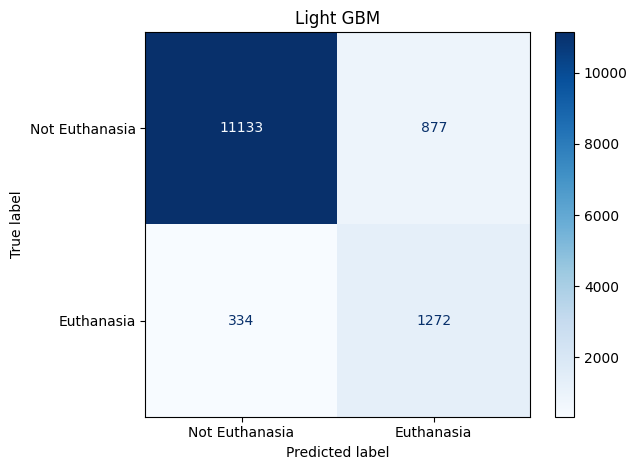

In [17]:
# 혼동행렬

cm = confusion_matrix(y_test2, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Euthanasia", "Euthanasia"])
disp.plot(cmap="Blues")
plt.title("Light GBM")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: U

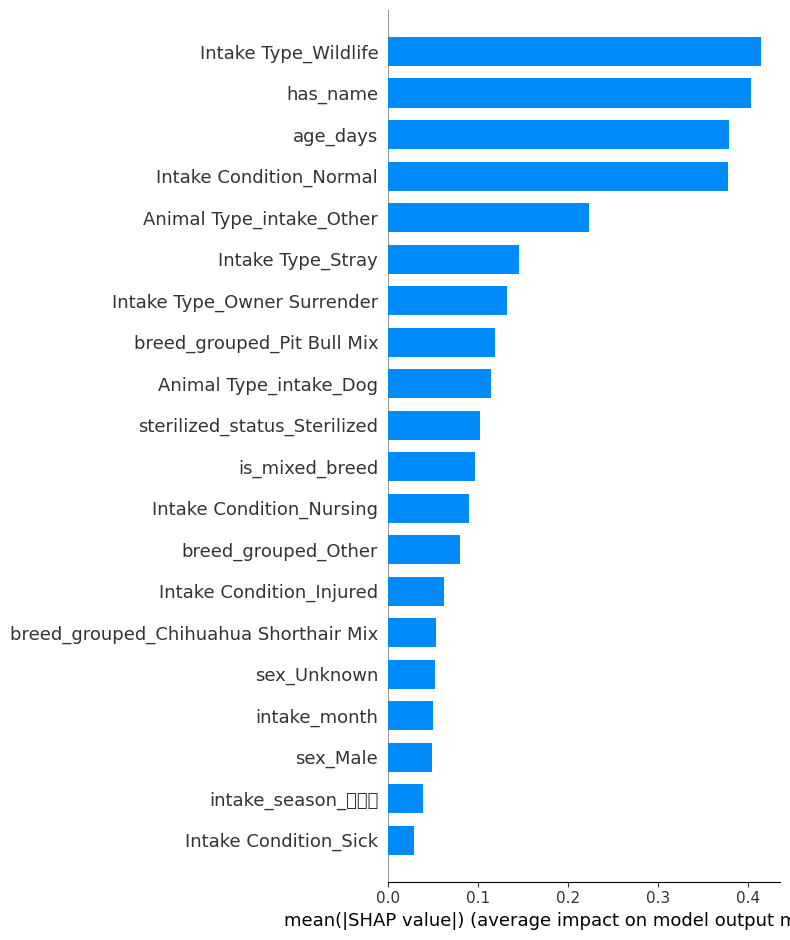

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: U

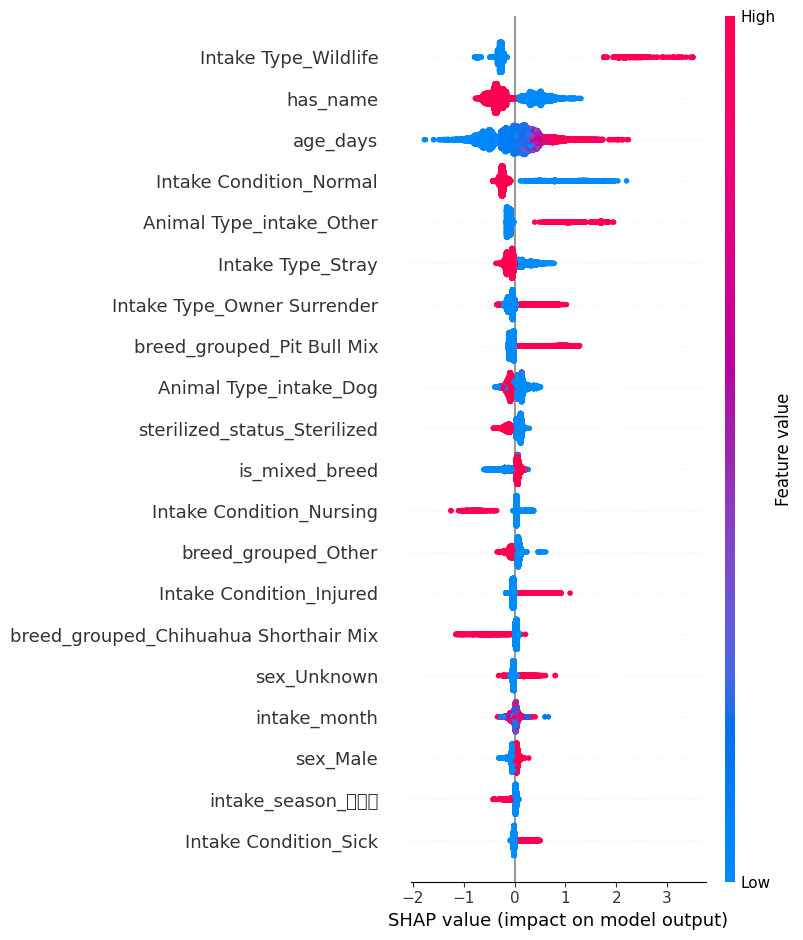

In [20]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(lgbm2)
shap_values = explainer(X_test2)
shap.summary_plot(
    shap_values,
    X_test2,
    plot_type="bar"
)

## 실제 예측에 기여한 변수 중요도
shap.summary_plot(
    shap_values,
    X_test2
)

## 변수 영향 방향
shap.plots.force(shap_values[0])

In [21]:
joblib.dump(lgbm2, "/content/drive/MyDrive/Matrix/Conference2026/lgbm2_model.pkl")
print("\n모델 저장 완료: lgbm2_model.pkl")


모델 저장 완료: lgbm2_model.pkl


# 전체 데이터 대상

In [22]:
grid = GridSearchCV(
    estimator = LGBMClassifier(
        random_state = 42, # 난수 고정
        class_weight = "balanced" # 클래스 불균형 보정
    ),
    param_grid = {
        "n_estimators" : [100, 200, 300],  # 생성할 트리 개수
        "learning_rate": [0.03, 0.05, 0.1], # 학습률
        "num_leaves": [15, 31, 63], # 한 트리의 최대 리프 수 (트리 복잡도 결정)
        "min_child_samples": [10, 20, 30] # 리프 노드의 최소 샘플 수 (과적합 방지)
    },
    scoring = "average_precision",  # PR-AUC 기준으로 최적 모델 선택
    cv = StratifiedKFold( # 각 Fold의 클래스 비율을 원본 데이터와 비슷하게 유지
          n_splits = 5,
          shuffle = True,
          random_state = 42
      ),
    n_jobs = -1
)

grid.fit(X_train3, y_train3)

# 최적 결과 출력
print("=" * 50)
print("Best Parameters")
print(grid.best_params_)
print()

print("Best Cross Validation PR-AUC")
print(f"{grid.best_score_:.4f}")
print("=" * 50)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6576, number of negative: 91677
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 182
[LightGBM] [Info] Number of data points in the train set: 98253, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best Parameters
{'learning_rate': 0.1, 'min_child_samples': 30, 'n_estimators': 200, 'num_leaves': 31}

Best Cross Validation PR-AUC
0.7422


In [23]:
lgbm3 = grid.best_estimator_

y_pred3 = lgbm3.predict(X_test3)
y_prob3 = lgbm3.predict_proba(X_test3)[:, 1]

In [24]:
# 성능 평가
accuracy = accuracy_score(y_test3, y_pred3) # 전체 예측 중 맞힌 비율
precision = precision_score(y_test3, y_pred3) # 안락사될 거라고 예측한 동물 중 실제 안락사된 비율
recall = recall_score(y_test3, y_pred3) # 실제 안락사된 동물 중 예측 성공한 비율
f1 = f1_score(y_test3, y_pred3) # Precision과 Recall의 균형
roc_auc = roc_auc_score(y_test3, y_prob3) # 모델이 두 클래스를 얼마나 잘 구분하는지
pr_auc = average_precision_score(y_test3, y_prob3) # 모델이 Precision과 Recall을 동시에 얼마나 잘 유지하는지

print("=" * 50)
print("LightGBM Performance")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test3, y_pred3))

print("\nClassification Report")
print(classification_report(y_test3, y_pred3))

LightGBM Performance
Accuracy : 0.9336
Precision: 0.5104
Recall   : 0.8154
F1 Score : 0.6278
ROC-AUC  : 0.9401
PR-AUC   : 0.7496

Confusion Matrix
[[21589  1322]
 [  312  1378]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     22911
           1       0.51      0.82      0.63      1690

    accuracy                           0.93     24601
   macro avg       0.75      0.88      0.80     24601
weighted avg       0.95      0.93      0.94     24601



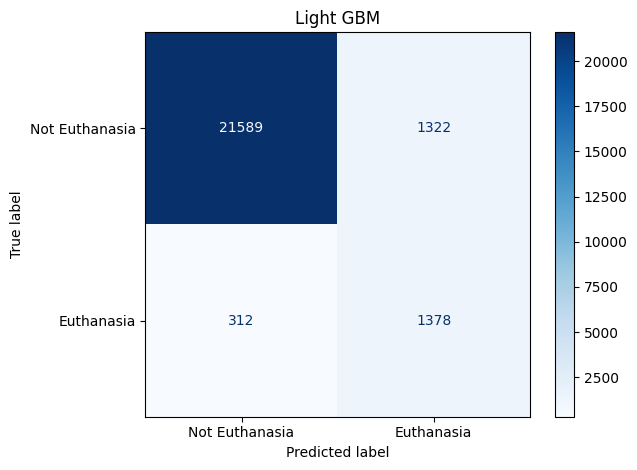

In [25]:
# 혼동행렬

cm = confusion_matrix(y_test3, y_pred3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Euthanasia", "Euthanasia"])
disp.plot(cmap="Blues")
plt.title("Light GBM")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: Use

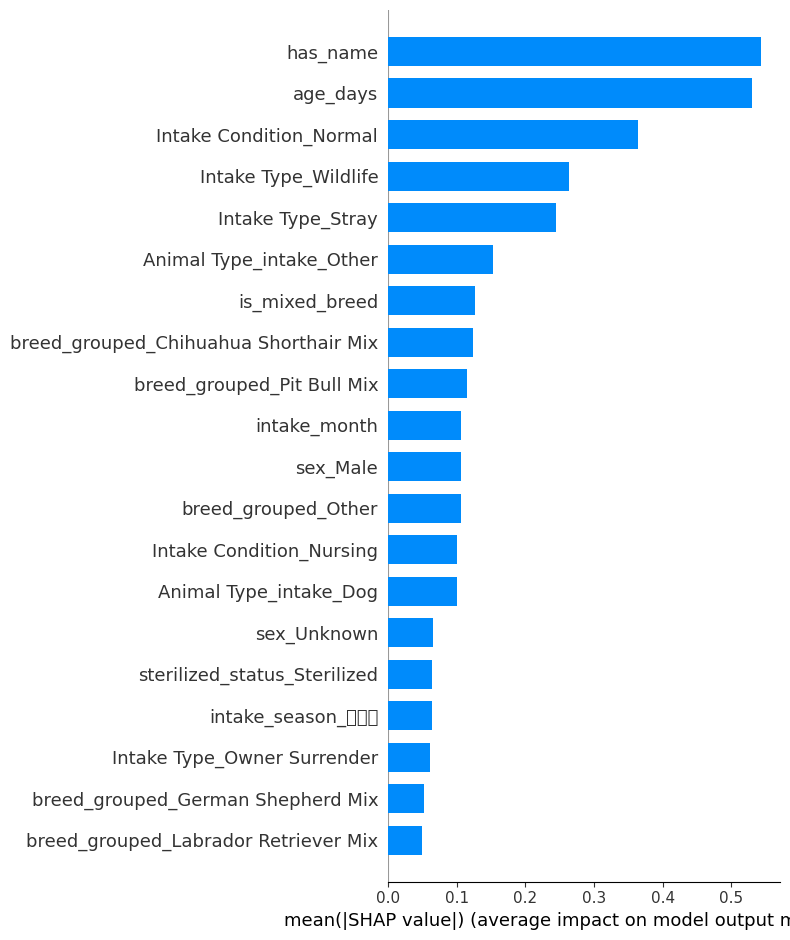

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: Use

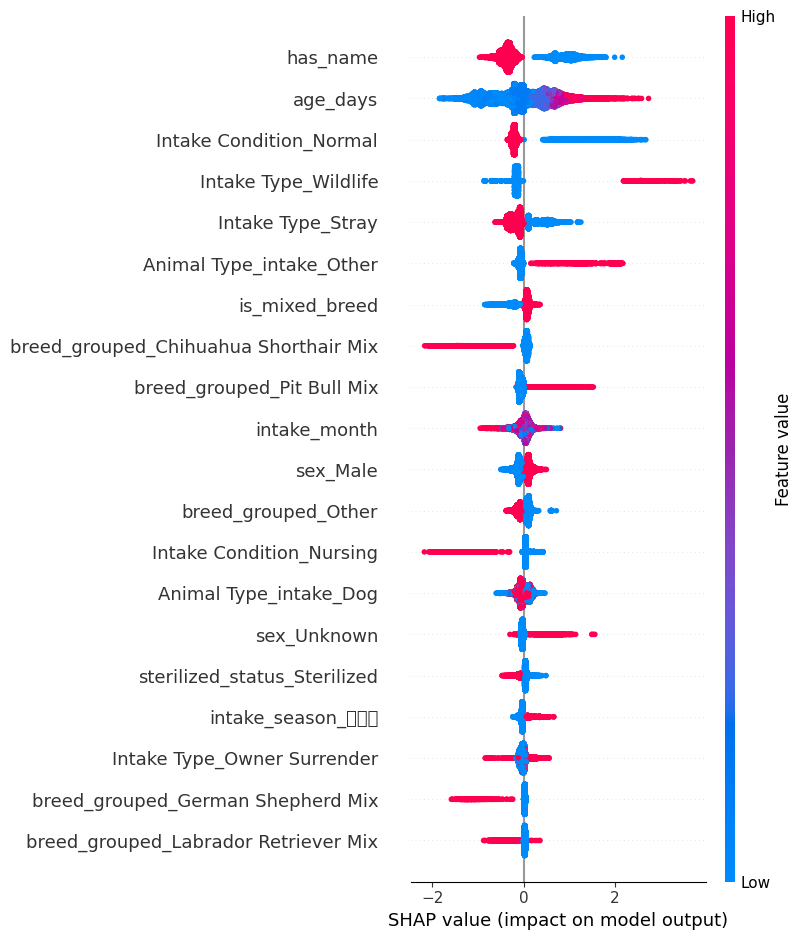

In [27]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(lgbm3)
shap_values = explainer(X_test3)
shap.summary_plot(
    shap_values,
    X_test3,
    plot_type = "bar"
)

## 실제 예측에 기여한 변수 중요도
shap.summary_plot(
    shap_values,
    X_test3
)

## 변수 영향 방향
shap.plots.force(shap_values[0])

In [28]:
joblib.dump(lgbm3, "/content/drive/MyDrive/Matrix/Conference2026/lgbm3_model.pkl")
print("\n모델 저장 완료: lgbm3_model.pkl")


모델 저장 완료: lgbm3_model.pkl
